### Intro

This dataset tracks traffic data throughout the various neighborhoods.  I chose to focus on the average_daily_car_traffic column as I felt it was the best overall metric for how busy an area would be, and how annoying it would be to drive in, so a lower average_daily_car_traffic would mean a better driving experience and a better neighborhood.

In [53]:
import pandas as pd

df = pd.read_csv("PittsburghTrafficData.csv")
df.head()

,_id,id,device_id,record_oid,count_start_date,count_end_date,average_daily_car_traffic,average_daily_bike_traffic,counter_number,counter_type,...,longitude,latitude,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone
0,1,1011743669,85,1.445865e+09,2019-04-18,2019-04-26,4949.0,NaN,6,StatTrak,...,-79.967772,40.455733,Polish Hill,7.0,6.0,42003060500,6.0,6.0,2.0,2-6
1,2,1026101993,140,1.121444e+09,2019-01-24,NaN,NaN,NaN,NaN,Intersection Study,...,-79.952249,40.466157,Central Lawrenceville,7.0,9.0,42003090200,2.0,9.0,2.0,3-6
2,3,1032382575,11,1.539893e+09,2018-08-28,2018-09-04,NaN,NaN,NaN,NaN,...,-80.076469,40.460717,Windgap,2.0,28.0,42003563000,5.0,28.0,6.0,1-16
3,4,103627606,9,7.341951e+08,2018-07-17,2018-08-01,2741.0,NaN,NaN,StatTrak,...,-79.914335,40.437379,Squirrel Hill South,5.0,14.0,42003140800,3.0,14.0,4.0,2-18
4,5,1039546167,144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-80.019211,40.490794,Perry North,1.0,26.0,42003260200,1.0,26.0,1.0,1-15


The first step after importing are data is cleaning and reorganizing it.  We need make sure that we only include trackers that have data for avg daily car traffic, and as it turns out, around 100 trackers across 10 neighborhood's are missing that data, so we need to drop them.

In [54]:
print("Missing neighborhoods: ",len(df["neighborhood"].unique()) - len(df.dropna(subset=["average_daily_car_traffic"])["neighborhood"].unique()))
print("Missing trackers:",len(df) - len(df.dropna(subset=["average_daily_car_traffic"])))

Missing neighborhoods:  10
Missing trackers: 134


In [ ]:
df = df.dropna(subset=["average_daily_car_traffic"])

Next, we need to set up the data for graphing.  Since there are multiple trackers per neighborhood, just plotting the data as is will only compare traffic data across the individual trackers.  We need to group by neighborhoods, and then take the mean of the daily traffic so we can compare the avg daily traffic across all the trackers for each neighborhood.

In [55]:
grouped_df = df.groupby(by="neighborhood")
grouped_df.head()

,_id,id,device_id,record_oid,count_start_date,count_end_date,average_daily_car_traffic,average_daily_bike_traffic,counter_number,counter_type,...,longitude,latitude,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone
0,1,1011743669,85,1.445865e+09,2019-04-18,2019-04-26,4949.0,NaN,6,StatTrak,...,-79.967772,40.455733,Polish Hill,7.0,6.0,42003060500,6.0,6.0,2.0,2-6
3,4,103627606,9,7.341951e+08,2018-07-17,2018-08-01,2741.0,NaN,NaN,StatTrak,...,-79.914335,40.437379,Squirrel Hill South,5.0,14.0,42003140800,3.0,14.0,4.0,2-18
5,6,1041392556,76,5.713472e+08,2019-03-22,2019-03-29,1046.0,NaN,2,StatTrak,...,-80.014234,40.458106,Central Northside,6.0,25.0,42003250300,1.0,25.0,1.0,1-21
7,8,1053645660,87,8.042089e+08,2019-04-18,2019-04-26,3015.0,NaN,4,StatTrak,...,-79.964592,40.457119,Polish Hill,7.0,6.0,42003060500,6.0,6.0,2.0,2-6
10,11,1102260248,8,1.088318e+09,2018-07-16,2018-08-01,5592.0,NaN,NaN,StatTrak,...,-79.911925,40.435620,Squirrel Hill South,5.0,14.0,42003140800,3.0,14.0,4.0,2-21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382,1226,504395374,401,1.119323e+09,2021-05-11,2021-05-19,2523.0,NaN,6,StatTrak,...,-79.991510,40.462082,Spring Hill-City View,1.0,24.0,42003262000,1.0,24.0,1.0,1-24
389,1321,434083600,408,1.452803e+09,2021-06-03,2021-06-11,2465.0,NaN,6,StatTrak,...,-79.869628,40.454185,East Hills,9.0,13.0,42003130600,2.0,13.0,5.0,3-19
393,1325,284761113,412,1.486634e+09,2021-06-03,2021-06-11,2585.0,NaN,2,StatTrak,...,-79.965519,40.440818,West Oakland,6.0,4.0,42003040200,3.0,4.0,4.0,2-10
402,1361,5216219,421,1.382452e+09,2021-06-29,2021-07-07,5605.0,NaN,7,StatTrak,...,-79.926715,40.425958,Greenfield,5.0,15.0,42003151700,3.0,15.0,4.0,2-15


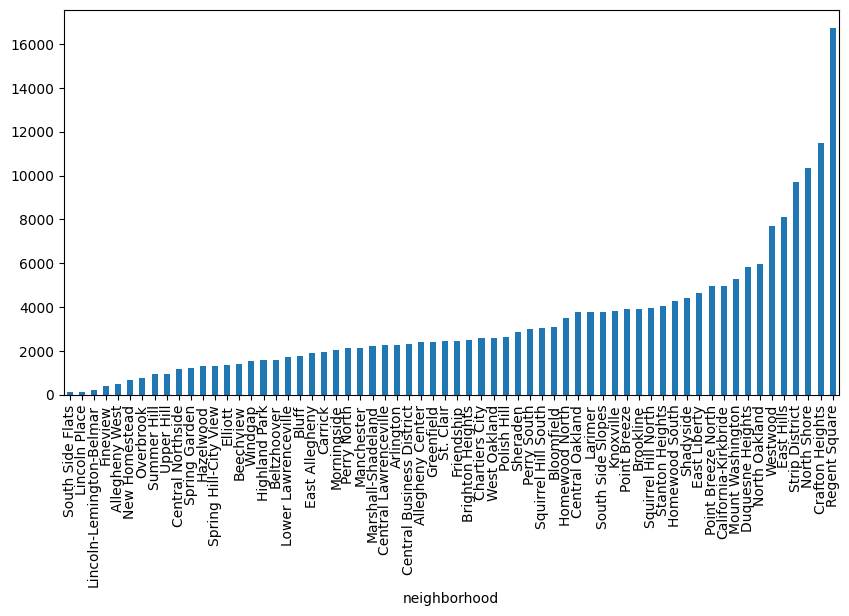

In [56]:
import matplotlib.pyplot as plt

grouped_df['average_daily_car_traffic'].mean().sort_values(ascending=True).plot(kind='bar', figsize=(10,5))
plt.show()

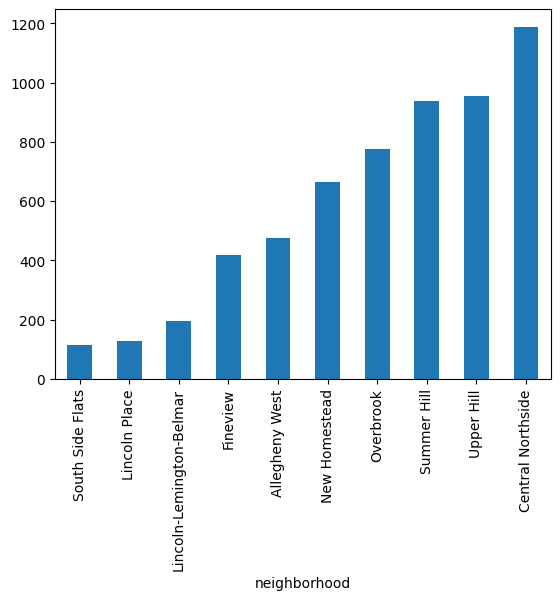

In [57]:
import matplotlib.pyplot as plt

grouped_df['average_daily_car_traffic'].mean().sort_values(ascending=True).head(10).plot(kind='bar')
plt.show()

In [58]:
final_df = grouped_df['average_daily_car_traffic'].mean().sort_values(ascending=True)
final_df.head()

neighborhood
South Side Flats            115.0
Lincoln Place               126.0
Lincoln-Lemington-Belmar    195.0
Fineview                    419.0
Allegheny West              477.0
Name: average_daily_car_traffic, dtype: float64

We can see that according to the traffic data, South Side Flats is the best neighborhood.

The biggest limitation for this dataset is the spread of datapoints.  Out of the 90 neighborhoods in Pittsburgh, this dataset only has information on 64 of them. so it isn't a complete representation of the city, and this will cause problems in integrating this dataset with the other two.

In [59]:
final_df.to_csv('traffic_final_data.csv')